<a href="https://colab.research.google.com/github/HonestyDisciplineConsistency/CSCI323-Group-Project/blob/main/CSCI323_Group_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# A Comparative Study of Naive Bayes and Decision Tree for Spam Email Detection

**Project focus:** Compare **Multinomial Naive Bayes** and **Decision Tree** classifiers for spam email detection using NLP/text classification.

Notebook workflow:

1. Dataset loading and inspection  
2. Text preprocessing  
3. TF-IDF feature extraction  
4. Naive Bayes model training  
5. Decision Tree model training  
6. Hyperparameter tuning  
7. Accuracy, precision, recall, F1-score, confusion matrix, and ROC-AUC  
8. Error analysis and marginal-case testing  
9. Report-ready result tables and plots  


## Import Required Libraries

These libraries are used for data handling, preprocessing, model training, model evaluation, and visualisation.

In [17]:
import os
import re
import zipfile
import urllib.request
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_validate
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline

from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Libraries imported successfully.")

Libraries imported successfully.


In [18]:
def read_csv_safely(file_path):
    """Read a CSV file using common encodings."""
    encodings = ["utf-8", "latin-1", "ISO-8859-1", "cp1252"]
    for enc in encodings:
        try:
            return pd.read_csv(file_path, encoding=enc)
        except UnicodeDecodeError:
            continue
    return pd.read_csv(file_path, encoding="latin-1")


def load_local_or_uci_dataset():
    """Load a local spam dataset if available, otherwise download UCI SMS Spam Collection."""
    possible_files = [
        "spam.csv",
        "spam_email.csv",
        "email_spam.csv",
        "emails.csv",
        "Spam Email raw text for NLP.csv",
        "spam_ham_dataset.csv"
    ]

    for filename in possible_files:
        file_path = Path(filename)
        if file_path.exists():
            print(f"Loaded local dataset: {filename}")
            return read_csv_safely(file_path)

    print("No local dataset found. Downloading UCI SMS Spam Collection as fallback...")
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip"
    zip_path = Path("smsspamcollection.zip")

    urllib.request.urlretrieve(url, zip_path)

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        with zip_ref.open("SMSSpamCollection") as file:
            df_uci = pd.read_csv(file, sep="\t", header=None, names=["label", "message"])

    print("Downloaded and loaded UCI SMS Spam Collection.")
    return df_uci


raw_df = load_local_or_uci_dataset()

print("Dataset shape:", raw_df.shape)
display(raw_df.head())
print("\nColumns:")
print(list(raw_df.columns))

No local dataset found. Downloading UCI SMS Spam Collection as fallback...
Downloaded and loaded UCI SMS Spam Collection.
Dataset shape: (5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."



Columns:
['label', 'message']


This cell attempts to find the label and message columns automatically, then converts them into a standard format:

- `label`
- `message`

In [19]:
def standardise_columns(df):
    """Detect and standardise label/message columns."""
    df = df.copy()

    # Remove fully empty columns sometimes found in spam.csv datasets
    df = df.dropna(axis=1, how="all")

    lower_cols = {str(col).strip().lower(): col for col in df.columns}

    label_candidates = [
        "label", "category", "class", "target", "type", "email type",
        "v1", "spam", "is_spam", "prediction"
    ]

    text_candidates = [
        "message", "text", "email", "email text", "body", "content",
        "v2", "subject", "mail"
    ]

    label_col = None
    text_col = None

    for candidate in label_candidates:
        if candidate in lower_cols:
            label_col = lower_cols[candidate]
            break

    for candidate in text_candidates:
        if candidate in lower_cols:
            text_col = lower_cols[candidate]
            break

    # If still not found, try using object columns
    if label_col is None or text_col is None:
        object_cols = [col for col in df.columns if df[col].dtype == "object"]

        if label_col is None:
            for col in object_cols:
                unique_values = df[col].dropna().astype(str).str.lower().unique()
                if any(value in ["spam", "ham", "not spam", "safe email", "phishing email"] for value in unique_values[:20]):
                    label_col = col
                    break

        if text_col is None:
            # Choose the text-like object column with highest average string length
            candidates = [col for col in object_cols if col != label_col]
            if candidates:
                text_col = max(candidates, key=lambda col: df[col].astype(str).str.len().mean())

    if label_col is None or text_col is None:
        raise ValueError(
            "Could not automatically detect label/message columns. "
            "Please rename your dataset columns to 'label' and 'message'."
        )

    df = df[[label_col, text_col]].copy()
    df.columns = ["label", "message"]

    return df


df = standardise_columns(raw_df)

print("Standardised dataset:")
display(df.head())
print("\nLabel values:")
print(df["label"].value_counts(dropna=False).head(20))

Standardised dataset:


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."



Label values:
label
ham     4825
spam     747
Name: count, dtype: int64


## Clean Labels

The target label is converted into numeric form:

- `0` = ham / non-spam / safe email  
- `1` = spam / phishing / suspicious email  


In [20]:
def map_label(value):
    """Map different possible label names to 0 = ham/non-spam and 1 = spam."""
    value = str(value).strip().lower()

    spam_values = {
        "spam", "1", "true", "yes", "phishing", "phishing email",
        "suspicious", "malicious", "fraud"
    }

    ham_values = {
        "ham", "0", "false", "no", "not spam", "non-spam", "non spam",
        "safe", "safe email", "legitimate", "normal"
    }

    if value in spam_values:
        return 1
    if value in ham_values:
        return 0

    return np.nan


df["label_num"] = df["label"].apply(map_label)
df = df.dropna(subset=["label_num"]).copy()
df["label_num"] = df["label_num"].astype(int)

print("Cleaned dataset shape:", df.shape)
print(df["label_num"].value_counts())
print("\n0 = Ham/Non-spam, 1 = Spam")

Cleaned dataset shape: (5572, 3)
label_num
0    4825
1     747
Name: count, dtype: int64

0 = Ham/Non-spam, 1 = Spam


## 5. Exploratory Data Analysis

Before training the models, we check:

1. Class distribution  
2. Message length distribution  
3. Example messages from each class  

This supports the report's **Dataset Preparation** section. The class distribution plot can be used as:

**Figure 1. Dataset class distribution.**

This helps explain that the dataset is imbalanced, with many more ham/non-spam messages than spam messages.


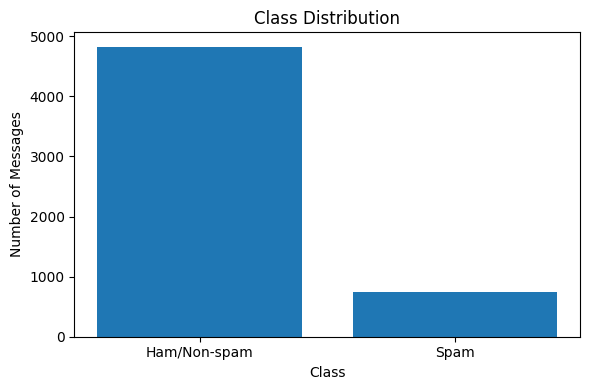

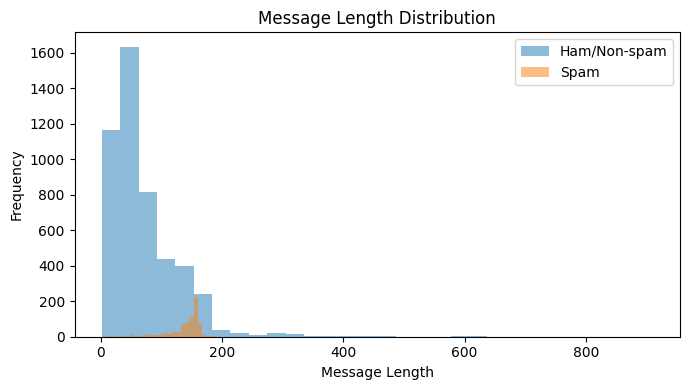

Example ham/non-spam messages:


,message
0,"Go until jurong point, crazy.. Available only ..."
1,Ok lar... Joking wif u oni...
3,U dun say so early hor... U c already then say...


Example spam messages:


,message
2,Free entry in 2 a wkly comp to win FA Cup fina...
5,FreeMsg Hey there darling it's been 3 week's n...
8,WINNER!! As a valued network customer you have...


In [21]:
label_counts = df["label_num"].value_counts().sort_index()
label_names = ["Ham/Non-spam", "Spam"]

plt.figure(figsize=(6, 4))
plt.bar(label_names, label_counts.values)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Messages")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "class_distribution.png", dpi=300)
plt.show()

df["message_length"] = df["message"].astype(str).str.len()

plt.figure(figsize=(7, 4))
df.groupby("label_num")["message_length"].plot(kind="hist", bins=30, alpha=0.5, legend=True)
plt.title("Message Length Distribution")
plt.xlabel("Message Length")
plt.ylabel("Frequency")
plt.legend(label_names)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "message_length_distribution.png", dpi=300)
plt.show()

print("Example ham/non-spam messages:")
display(df[df["label_num"] == 0][["message"]].head(3))

print("Example spam messages:")
display(df[df["label_num"] == 1][["message"]].head(3))

## 6. Text Preprocessing

Text preprocessing reduces noise before feature extraction.

The cleaning function below:

- Converts text to lowercase
- Removes URLs
- Removes email addresses
- Removes non-alphabetical characters
- Removes extra spaces

Stop words are removed later by `TfidfVectorizer`.

In [22]:
def clean_text(text):
    """Clean raw message text for spam classification."""
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)          # remove URLs
    text = re.sub(r"\S+@\S+", " ", text)                 # remove email addresses
    text = re.sub(r"[^a-zA-Z\s]", " ", text)             # keep letters and spaces only
    text = re.sub(r"\s+", " ", text).strip()             # remove extra spaces
    return text


df["clean_message"] = df["message"].apply(clean_text)

display(df[["message", "clean_message", "label_num"]].head())

,message,clean_message,label_num
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...,0
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...,1
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say,0
4,"Nah I don't think he goes to usf, he lives aro...",nah i don t think he goes to usf he lives arou...,0


## 7. Mathematical Theory Used in This Experiment

### 7.1 TF-IDF

TF-IDF gives importance to words that appear frequently in one document but are not too common across the whole dataset.

\[
\text{TF-IDF}(t,d) = \text{TF}(t,d) \times \text{IDF}(t)
\]

A word such as **"free"** or **"winner"** may be useful if it appears strongly in spam messages.

### 7.2 Naive Bayes

Naive Bayes applies Bayes' theorem:

\[
P(C \mid x) = \frac{P(x \mid C)P(C)}{P(x)}
\]

For text classification, the model estimates the probability that a message belongs to a class, such as spam or ham, based on its words.

### 7.3 Decision Tree

A Decision Tree splits the dataset based on feature values. One common splitting measure is **Gini impurity**:

\[
Gini = 1 - \sum_{k=1}^{K} p_k^2
\]

A lower impurity means the split separates the classes more clearly.

### 7.4 Evaluation Metrics

\[
Accuracy = \frac{TP + TN}{TP + TN + FP + FN}
\]

\[
Precision = \frac{TP}{TP + FP}
\]

\[
Recall = \frac{TP}{TP + FN}
\]

\[
F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}
\]

For spam detection, both **false positives** and **false negatives** matter:

- False positive: a normal message is wrongly classified as spam.
- False negative: a spam message is wrongly classified as normal.

## 8. Train-Test Split

The dataset is split into:

- 80% training data
- 20% testing data

`stratify=y` is used so that the spam/ham ratio is preserved in both sets.

In [23]:
X = df["clean_message"]
y = df["label_num"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])
print("\nTraining label distribution:")
print(y_train.value_counts(normalize=True))
print("\nTesting label distribution:")
print(y_test.value_counts(normalize=True))

Training set size: 4457
Testing set size: 1115

Training label distribution:
label_num
0    0.865829
1    0.134171
Name: proportion, dtype: float64

Testing label distribution:
label_num
0    0.866368
1    0.133632
Name: proportion, dtype: float64


## 9. Model Pipelines

Both models use the same TF-IDF representation to keep the comparison fair.

### Model 1: Multinomial Naive Bayes
Suitable for text classification because it works well with word frequency or TF-IDF style features.

### Model 2: Decision Tree
Useful because its decision rules are easier to interpret, but it may overfit high-dimensional text features.

In [24]:
nb_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english")),
    ("model", MultinomialNB())
])

dt_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english")),
    ("model", DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced"))
])

print("Model pipelines created.")

Model pipelines created.


## 10. Hyperparameter Tuning

To make the comparison stronger, the notebook uses `GridSearchCV`.

The scoring metric is **F1-score** because spam detection must balance:

- Precision: avoid wrongly marking normal emails as spam
- Recall: catch as much spam as possible

If this cell takes too long, set `RUN_GRID_SEARCH = False`.

In [ ]:
RUN_GRID_SEARCH = True

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

nb_param_grid = {
    "tfidf__max_features": [3000, 5000],
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "model__alpha": [0.1, 0.5, 1.0]
}

dt_param_grid = {
    "tfidf__max_features": [3000, 5000],
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "model__criterion": ["gini", "entropy"],
    "model__max_depth": [10, 20, 40],
    "model__min_samples_leaf": [1, 3]
}

if RUN_GRID_SEARCH:
    nb_search = GridSearchCV(
        nb_pipeline,
        nb_param_grid,
        cv=cv,
        scoring="f1",
        n_jobs=-1
    )

    dt_search = GridSearchCV(
        dt_pipeline,
        dt_param_grid,
        cv=cv,
        scoring="f1",
        n_jobs=-1
    )

    print("Tuning Naive Bayes...")
    nb_search.fit(X_train, y_train)

    print("Tuning Decision Tree...")
    dt_search.fit(X_train, y_train)

    best_nb = nb_search.best_estimator_
    best_dt = dt_search.best_estimator_

    print("\nBest Naive Bayes parameters:")
    print(nb_search.best_params_)
    print("Best Naive Bayes CV F1:", nb_search.best_score_)

    print("\nBest Decision Tree parameters:")
    print(dt_search.best_params_)
    print("Best Decision Tree CV F1:", dt_search.best_score_)
else:
    best_nb = nb_pipeline.fit(X_train, y_train)
    best_dt = dt_pipeline.fit(X_train, y_train)

    print("Grid search skipped. Baseline models trained.")

Tuning Naive Bayes...
Tuning Decision Tree...


## 11. Evaluate Models on the Test Set

The models are evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Confusion matrix
- Classification report

In [ ]:
def get_positive_probability(model, X_values):
    """Return probability for class 1 = spam."""
    probabilities = model.predict_proba(X_values)
    class_list = list(model.classes_)
    spam_index = class_list.index(1)
    return probabilities[:, spam_index]


def evaluate_model(model_name, model, X_test, y_test):
    """Evaluate a trained model and return a dictionary of metrics."""
    y_pred = model.predict(X_test)
    y_proba = get_positive_probability(model, X_test)

    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    }

    print("=" * 70)
    print(model_name)
    print("=" * 70)
    print(pd.Series(metrics).drop("Model"))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=["Ham/Non-spam", "Spam"]))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Ham/Non-spam", "Spam"])
    disp.plot(values_format="d")
    plt.title(f"{model_name} Confusion Matrix")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"{model_name.lower().replace(' ', '_')}_confusion_matrix.png", dpi=300)
    plt.show()

    return metrics, y_pred, y_proba


nb_metrics, nb_pred, nb_proba = evaluate_model("Naive Bayes", best_nb, X_test, y_test)
dt_metrics, dt_pred, dt_proba = evaluate_model("Decision Tree", best_dt, X_test, y_test)

results_df = pd.DataFrame([nb_metrics, dt_metrics])
display(results_df)
results_df.to_csv(OUTPUT_DIR / "model_comparison_metrics.csv", index=False)

## 12. ROC Curve Comparison

ROC-AUC helps show how well the model separates spam from non-spam across different thresholds.

In [ ]:
plt.figure(figsize=(7, 5))

RocCurveDisplay.from_predictions(y_test, nb_proba, name="Naive Bayes")
RocCurveDisplay.from_predictions(y_test, dt_proba, name="Decision Tree")

plt.title("ROC Curve Comparison")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "roc_curve_comparison.png", dpi=300)
plt.show()

## 13. Model Comparison Plot

This chart gives a quick visual comparison of both models across the main evaluation metrics.

Use the saved image `outputs/model_comparison_bar_chart.png` as:

**Figure 2. Naive Bayes vs Decision Tree performance comparison.**


In [ ]:
plot_metrics = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
ax = results_df.set_index("Model")[plot_metrics].plot(kind="bar", figsize=(9, 5))
plt.title("Naive Bayes vs Decision Tree Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "model_comparison_bar_chart.png", dpi=300)
plt.show()

## 14. Cross-Validation Comparison

Cross-validation gives a more stable estimate of model performance by testing the model across multiple folds of the training data.

In [ ]:
scoring = ["accuracy", "precision", "recall", "f1"]

cv_results = []

for model_name, model in [("Naive Bayes", best_nb), ("Decision Tree", best_dt)]:
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    row = {"Model": model_name}
    for metric in scoring:
        row[f"{metric}_mean"] = scores[f"test_{metric}"].mean()
        row[f"{metric}_std"] = scores[f"test_{metric}"].std()

    cv_results.append(row)

cv_results_df = pd.DataFrame(cv_results)
display(cv_results_df)
cv_results_df.to_csv(OUTPUT_DIR / "cross_validation_results.csv", index=False)

## 15. Feature Interpretation

This section helps explain **why** the models make certain predictions.

### Naive Bayes
For Naive Bayes, we inspect words that are more strongly associated with spam.

### Decision Tree
For Decision Tree, we inspect the most important TF-IDF features used in splits.

This supports the report requirement to explain why a model performs well under certain conditions.

In [ ]:
def show_naive_bayes_top_words(nb_model, top_n=20):
    vectorizer = nb_model.named_steps["tfidf"]
    model = nb_model.named_steps["model"]

    feature_names = np.array(vectorizer.get_feature_names_out())

    class_list = list(model.classes_)
    ham_index = class_list.index(0)
    spam_index = class_list.index(1)

    spam_strength = model.feature_log_prob_[spam_index] - model.feature_log_prob_[ham_index]

    top_spam_indices = np.argsort(spam_strength)[-top_n:][::-1]
    top_ham_indices = np.argsort(spam_strength)[:top_n]

    top_spam = pd.DataFrame({
        "Word": feature_names[top_spam_indices],
        "Spam Association Score": spam_strength[top_spam_indices]
    })

    top_ham = pd.DataFrame({
        "Word": feature_names[top_ham_indices],
        "Ham Association Score": spam_strength[top_ham_indices]
    })

    return top_spam, top_ham


def show_decision_tree_top_features(dt_model, top_n=20):
    vectorizer = dt_model.named_steps["tfidf"]
    model = dt_model.named_steps["model"]

    feature_names = np.array(vectorizer.get_feature_names_out())
    importances = model.feature_importances_

    top_indices = np.argsort(importances)[-top_n:][::-1]

    return pd.DataFrame({
        "Feature": feature_names[top_indices],
        "Importance": importances[top_indices]
    })


top_spam_words, top_ham_words = show_naive_bayes_top_words(best_nb, top_n=20)
dt_top_features = show_decision_tree_top_features(best_dt, top_n=20)

print("Top words associated with spam according to Naive Bayes:")
display(top_spam_words)

print("Top words associated with ham/non-spam according to Naive Bayes:")
display(top_ham_words)

print("Top Decision Tree features:")
display(dt_top_features)

top_spam_words.to_csv(OUTPUT_DIR / "naive_bayes_top_spam_words.csv", index=False)
top_ham_words.to_csv(OUTPUT_DIR / "naive_bayes_top_ham_words.csv", index=False)
dt_top_features.to_csv(OUTPUT_DIR / "decision_tree_top_features.csv", index=False)

## 17. Error Analysis

This section identifies false positives and false negatives.

- **False Positive:** Ham/non-spam message wrongly classified as spam.
- **False Negative:** Spam message wrongly classified as ham/non-spam.

In spam detection, false positives may hide important emails, while false negatives may allow harmful spam to reach the inbox.

In [ ]:
test_analysis = pd.DataFrame({
    "message": X_test.index.map(df["message"]),
    "clean_message": X_test.values,
    "true_label": y_test.values,
    "nb_pred": nb_pred,
    "dt_pred": dt_pred,
    "nb_spam_probability": nb_proba,
    "dt_spam_probability": dt_proba
})

def show_errors(model_pred_col, model_name, max_examples=5):
    false_positives = test_analysis[
        (test_analysis["true_label"] == 0) & (test_analysis[model_pred_col] == 1)
    ]

    false_negatives = test_analysis[
        (test_analysis["true_label"] == 1) & (test_analysis[model_pred_col] == 0)
    ]

    print("=" * 70)
    print(model_name)
    print("=" * 70)

    print(f"False positives: {len(false_positives)}")
    display(false_positives[["message", "true_label", model_pred_col]].head(max_examples))

    print(f"False negatives: {len(false_negatives)}")
    display(false_negatives[["message", "true_label", model_pred_col]].head(max_examples))


show_errors("nb_pred", "Naive Bayes")
show_errors("dt_pred", "Decision Tree")

test_analysis.to_csv(OUTPUT_DIR / "test_error_analysis.csv", index=False)

## 18. Marginal Case Testing

Marginal cases are messages that are difficult to classify because they contain features of both spam and ham.

Examples include:

- A real marketing email with words like "free" or "discount"
- A short message with very little context
- A phishing-style message that sounds professional
- A normal message that uses urgent language
- Spam that avoids obvious spam keywords

In [ ]:
marginal_cases = [
    "Congratulations, you have won a free voucher. Claim your reward now.",
    "Hi, can you send me the report by tonight? It is urgent.",
    "Your account requires verification. Please login to confirm your details.",
    "Limited time discount available for selected customers only.",
    "Are we still meeting for project discussion tomorrow?",
    "Dear user, your mailbox storage is almost full. Click here to upgrade.",
    "Free entry in a weekly competition to win cash prizes.",
    "Please review the attached invoice and confirm payment.",
]

marginal_df = pd.DataFrame({"message": marginal_cases})
marginal_df["clean_message"] = marginal_df["message"].apply(clean_text)

marginal_df["Naive Bayes Prediction"] = best_nb.predict(marginal_df["clean_message"])
marginal_df["Naive Bayes Spam Probability"] = get_positive_probability(best_nb, marginal_df["clean_message"])

marginal_df["Decision Tree Prediction"] = best_dt.predict(marginal_df["clean_message"])
marginal_df["Decision Tree Spam Probability"] = get_positive_probability(best_dt, marginal_df["clean_message"])

marginal_df["Naive Bayes Prediction"] = marginal_df["Naive Bayes Prediction"].map({0: "Ham/Non-spam", 1: "Spam"})
marginal_df["Decision Tree Prediction"] = marginal_df["Decision Tree Prediction"].map({0: "Ham/Non-spam", 1: "Spam"})

display(marginal_df)

marginal_df.to_csv(OUTPUT_DIR / "marginal_case_predictions.csv", index=False)